In [2]:
import numpy as np
import matplotlib.pyplot as plt 


In [3]:
a = -1
b = 1
z = np.linspace(-1, 1, num=100)

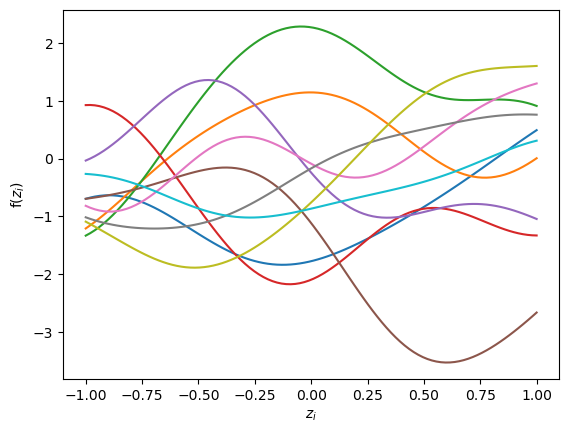

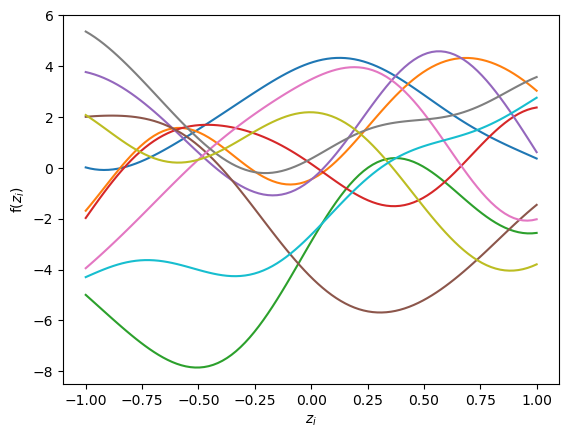

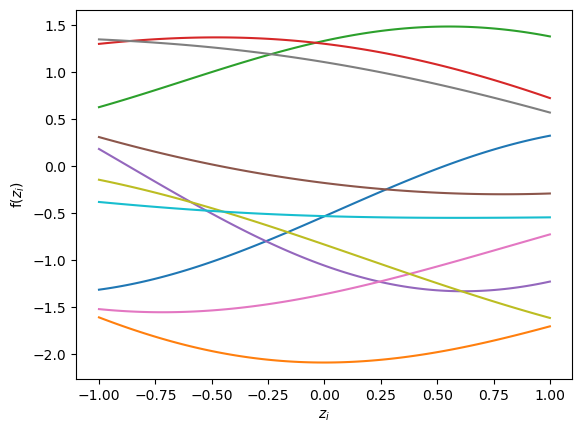

In [4]:
# kernel function
def kernel_funct(zi,zj,theta_0,theta_1):
    return theta_0* np.exp(-theta_1/2*(zi-zj)**2)


thetas = [(1,4),(9,4),(1,0.25)]

num_samples = 10

for theta_0, theta_1 in thetas:
    # kernel matrix 

    ker = np.zeros((len(z), len(z)))  
    for i in range(len(z)):
        for j in range(len(z)):
            ker[i, j] = kernel_funct(z[i], z[j], theta_0, theta_1)
            
    # Sample from GP (mean = 0)       
    samples = np.random.multivariate_normal(mean=np.zeros(len(z)), cov=ker, size=num_samples)
    

    for i in range(num_samples):
            plt.plot(z, samples[i], label=f'Sample {i+1}')
    #plt.title(f'Theta values:({theta_0},{theta_1})')
    plt.xlabel('$z_i$')
    plt.ylabel('f($z_i$)')
    # plt.legend()
    plt.show()


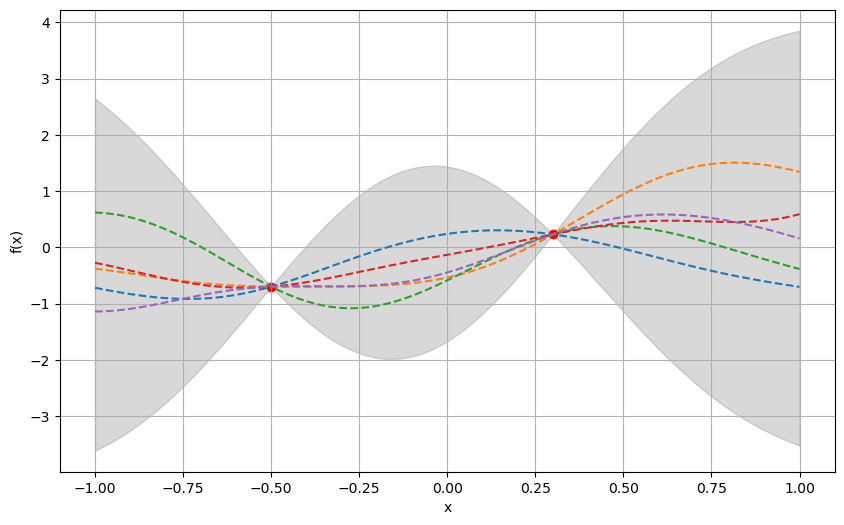

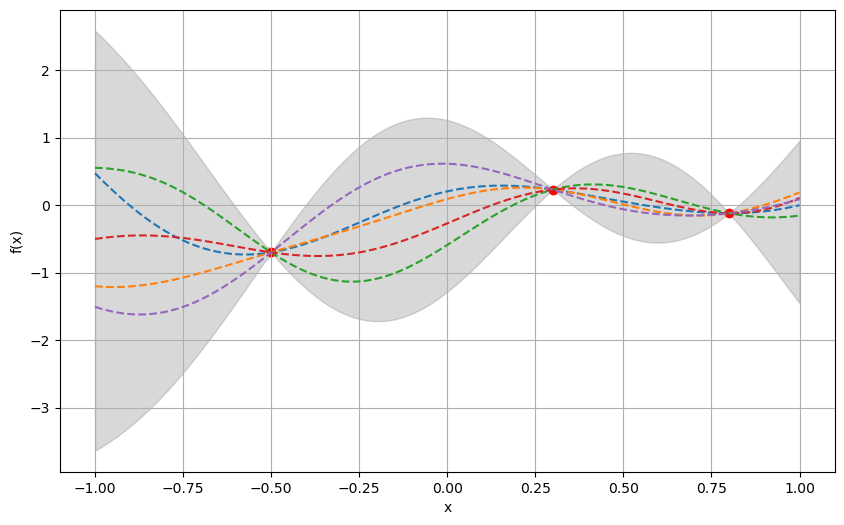

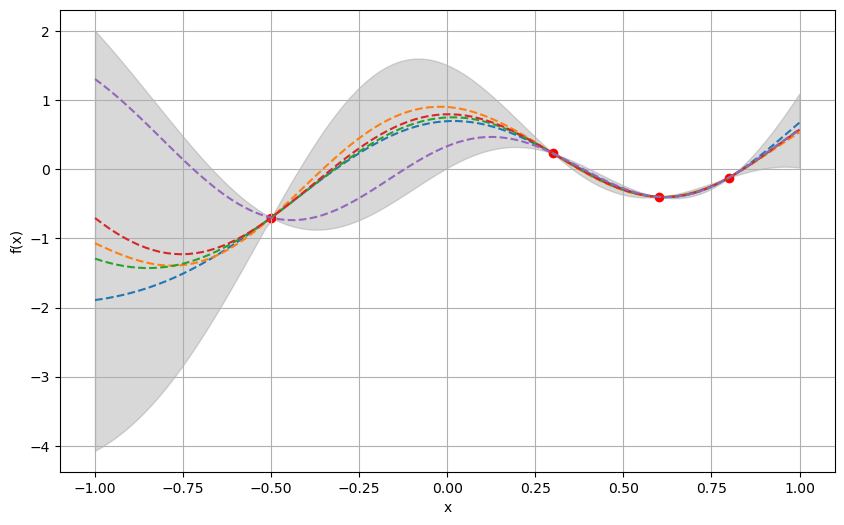

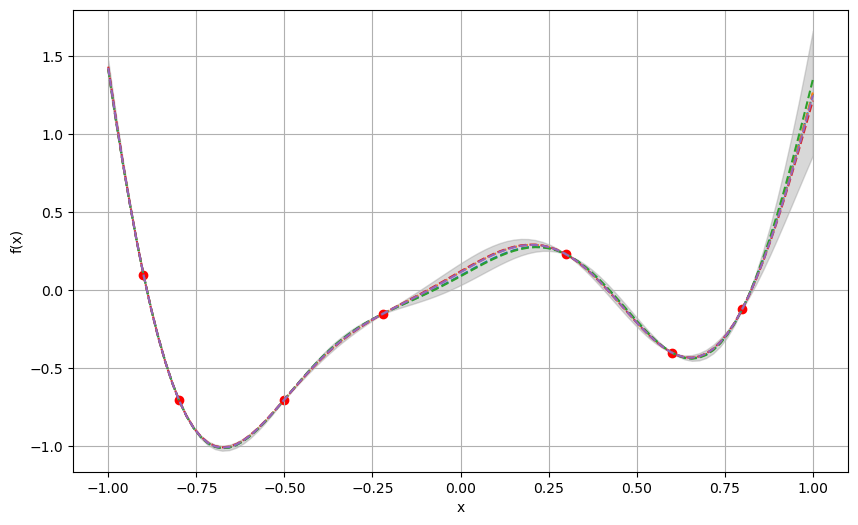

In [5]:

# Datasets with increasing training points
datasets = [
    (np.array([0.3, -0.5]), np.array([0.23, -0.7])),
    (np.array([0.3, -0.5, 0.8]), np.array([0.23, -0.7, -0.12])),
    (np.array([0.3, -0.5, 0.8, 0.6]), np.array([0.23, -0.7, -0.12, -0.4])),
    (np.array([0.3, -0.5, 0.8, 0.6, -0.9, -0.22, -0.80]),
     np.array([0.23, -0.7, -0.12, -0.4, 0.1, -0.15, -0.7]))
]

# Test data
X_test = np.linspace(-1, 1, 100)

# Hyperparameters
theta_0 = 1.0
theta_1 = 4.0
sigma_2 = 0.0

# Number of posterior samples (same for all datasets)
n_samples = 5

# Kernel function
def kernel_funct_matrix(x1, x2, theta_0, theta_1):
    sq_differ = (np.subtract.outer(x1, x2)) ** 2
    return theta_0 * np.exp(-theta_1 / 2 * sq_differ)

# Covariance matrices
def matrices(X_train, X_test, theta_0, theta_1, sigma_2):
    C_N = kernel_funct_matrix(X_train, X_train, theta_0, theta_1) + sigma_2 * np.eye(len(X_train))
    K_mat = kernel_funct_matrix(X_train, X_test, theta_0, theta_1)
    D = kernel_funct_matrix(X_test, X_test, theta_0, theta_1) + sigma_2 * np.eye(len(X_test))
    return C_N, K_mat, D

# Loop over datasets
for idx, (X_train, y_train) in enumerate(datasets, 1):
    # GP posterior
    C_N, K_mat, D = matrices(X_train, X_test, theta_0, theta_1, sigma_2)
    C_N_inv = np.linalg.inv(C_N)

    mean_vector = K_mat.T @ C_N_inv @ y_train
    cov_matrix = D - K_mat.T @ C_N_inv @ K_mat
    std_dev = np.sqrt(np.diag(cov_matrix))

    # Samples from the posterior
    samples = np.random.multivariate_normal(mean_vector, cov_matrix, size=n_samples)

    # Plot
    plt.figure(figsize=(10, 6))
    upper_bound = mean_vector + 4 * std_dev
    lower_bound = mean_vector - 4 * std_dev
    plt.fill_between(X_test, lower_bound, upper_bound, color='gray', alpha=0.3, label="±4 Std. Dev.")

    for i, sample in enumerate(samples):
        plt.plot(X_test, sample, linestyle='--', label=f"Sample {i+1}")

    plt.scatter(X_train, y_train, color='red', label='Training Data')

    #plt.title(rf"Gaussian Process Posterior with $\pm 4\,\sigma$ bounds")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True)
    plt.show()


In the following snippet, $\beta^{-1}$ is nonzero.

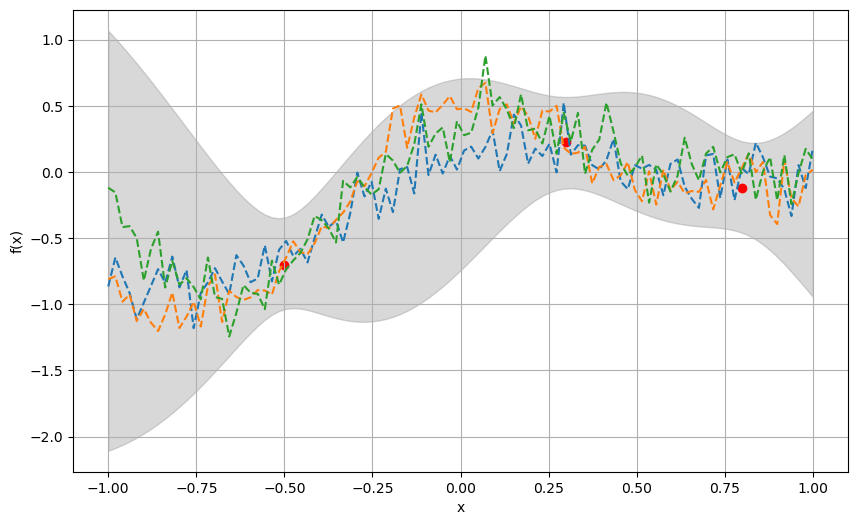

375.4309730149192
3.6228999441300433e-16


In [6]:

# Training data (3 observations)
X_train = np.array([0.3, -0.5, 0.8])
y_train = np.array([0.23, -0.7, -0.12])

# Test data
X_test = np.linspace(-1, 1, 100)

# Hyperparameters
theta_0 = 1.0
theta_1 = 4.0
sigma_2 = 1e-2

# Vectorized kernel using your definition
def kernel_funct_matrix(x1, x2, theta_0, theta_1):
    sq_differ = (np.subtract.outer(x1, x2)) ** 2
    return theta_0 * np.exp(-theta_1 / 2 * sq_differ)

# Compute covariance matrices
def matrices(X_train, X_test, theta_0, theta_1, sigma_2):
    C_N = kernel_funct_matrix(X_train, X_train, theta_0, theta_1) + sigma_2 * np.eye(len(X_train))
    K_mat = kernel_funct_matrix(X_train, X_test, theta_0, theta_1)
    D = kernel_funct_matrix(X_test, X_test, theta_0, theta_1) + sigma_2 * np.eye(len(X_test))
    return C_N, K_mat, D

# GP posterior
C_N, K_mat, D = matrices(X_train, X_test, theta_0, theta_1, sigma_2)
C_N_inv = np.linalg.inv(C_N)

mean_vector = K_mat.T @ C_N_inv @ y_train
cov_matrix = D - K_mat.T @ C_N_inv @ K_mat + sigma_2 * np.eye(len(X_test))
std_dev = np.sqrt(np.diag(cov_matrix))

# samples from the posterior
n_samples = 3
samples = np.random.multivariate_normal(mean_vector, cov_matrix, size=n_samples)

# Plot ±4 std deviation confidence bounds
plt.figure(figsize=(10, 6))
upper_bound = mean_vector + 2 * std_dev
lower_bound = mean_vector - 2 * std_dev
plt.fill_between(X_test, lower_bound, upper_bound, color='gray', alpha=0.3, label="±4 Std. Dev.")

# Plot samples
for i, sample in enumerate(samples):
    plt.plot(X_test, sample, label=f"Sample {i+1}", linestyle='--')

# Training data
plt.scatter(X_train, y_train, color='red', label='Training Data')

# Final plot settings
#plt.title(r"Gaussian Process Posterior with $\pm 4\,\sigma$ confidence bounds")
plt.xlabel("x")
plt.ylabel("f(x)")

plt.grid(True)
plt.show()
print(np.linalg.cond(cov_matrix))
x=C_N @ C_N_inv
print(np.linalg.norm(x-np.eye(x.shape[0])))

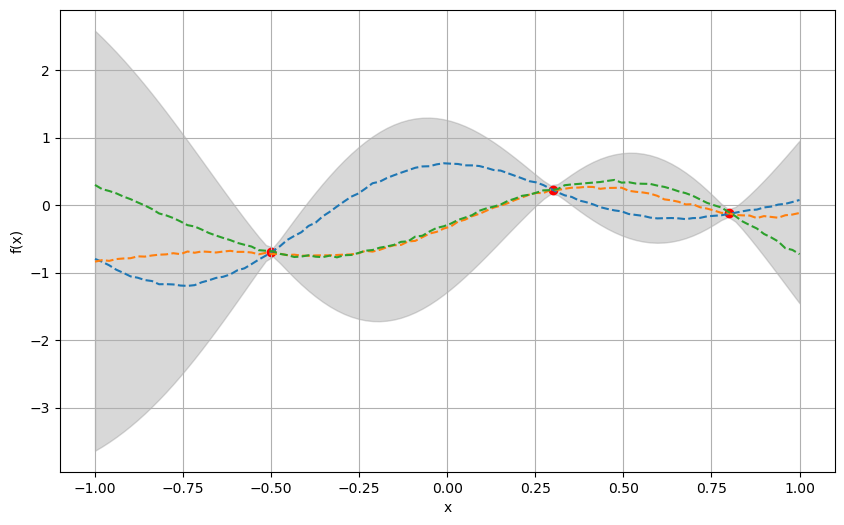

In [7]:

# Training data (3 observations)
X_train = np.array([0.3, -0.5, 0.8])
y_train = np.array([0.23, -0.7, -0.12])

# Test data
X_test = np.linspace(-1, 1, 100)

# Hyperparameters
theta_0 = 1.0
theta_1 = 4.0
sigma_2 = 1e-4

# Vectorized kernel using your definition
def kernel_funct_matrix(x1, x2, theta_0, theta_1):
    sq_differ = (np.subtract.outer(x1, x2)) ** 2
    return theta_0 * np.exp(-theta_1 / 2 * sq_differ)

# Compute covariance matrices
def matrices(X_train, X_test, theta_0, theta_1, sigma_2):
    C_N = kernel_funct_matrix(X_train, X_train, theta_0, theta_1) + sigma_2 * np.eye(len(X_train))
    K_mat = kernel_funct_matrix(X_train, X_test, theta_0, theta_1)
    D = kernel_funct_matrix(X_test, X_test, theta_0, theta_1) + sigma_2 * np.eye(len(X_test))
    return C_N, K_mat, D

# GP posterior
C_N, K_mat, D = matrices(X_train, X_test, theta_0, theta_1, sigma_2)
C_N_inv = np.linalg.inv(C_N)

mean_vector = K_mat.T @ C_N_inv @ y_train
cov_matrix = D - K_mat.T @ C_N_inv @ K_mat
std_dev = np.sqrt(np.diag(cov_matrix))

# samples from the posterior
n_samples = 3
samples = np.random.multivariate_normal(mean_vector, cov_matrix, size=n_samples)

# Plot ±4 std deviation confidence bounds
plt.figure(figsize=(10, 6))
upper_bound = mean_vector + 4 * std_dev
lower_bound = mean_vector - 4 * std_dev
plt.fill_between(X_test, lower_bound, upper_bound, color='gray', alpha=0.3, label="±4 Std. Dev.")

# Plot samples
for i, sample in enumerate(samples):
    plt.plot(X_test, sample, label=f"Sample {i+1}", linestyle='--')

# Training data
plt.scatter(X_train, y_train, color='red', label='Training Data')

# Final plot settings
#plt.title(r"Gaussian Process Posterior with $\pm 4\,\sigma$ confidence bounds")
plt.xlabel("x")
plt.ylabel("f(x)")

plt.grid(True)
plt.show()


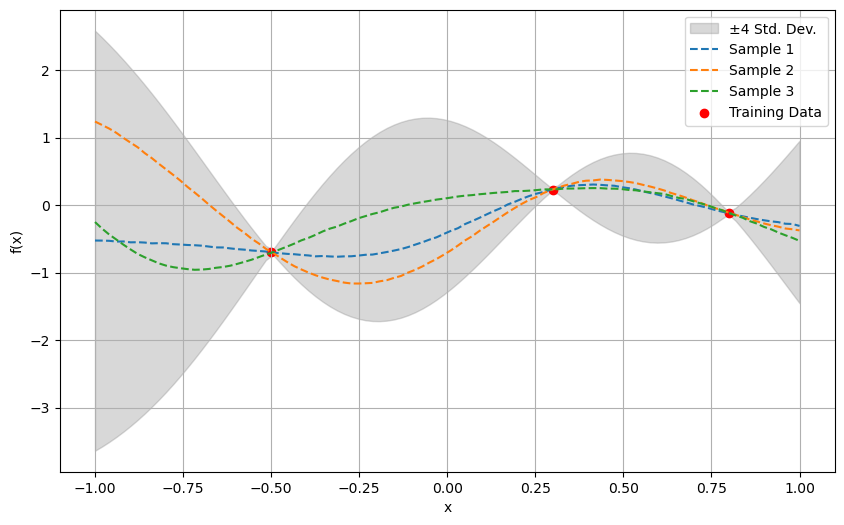

Norm of (C_N × solve(C_N, I) - I): 1.623496975204672e-16


In [8]:
# Training data
X_train = np.array([0.3, -0.5, 0.8])
y_train = np.array([0.23, -0.7, -0.12])

# Test data
X_test = np.linspace(-1, 1, 100)

# Hyperparameters
theta_0 = 1.0
theta_1 = 4.0
sigma_2 = 1e-5

# Kernel function
def kernel_funct_matrix(x1, x2, theta_0, theta_1):
    sq_differ = (np.subtract.outer(x1, x2)) ** 2
    return theta_0 * np.exp(-theta_1 / 2 * sq_differ)

# Compute covariance matrices
def matrices(X_train, X_test, theta_0, theta_1, sigma_2):
    C_N = kernel_funct_matrix(X_train, X_train, theta_0, theta_1) + sigma_2 * np.eye(len(X_train))
    K_mat = kernel_funct_matrix(X_train, X_test, theta_0, theta_1)
    D = kernel_funct_matrix(X_test, X_test, theta_0, theta_1)
    return C_N, K_mat, D

# GP posterior
C_N, K_mat, D = matrices(X_train, X_test, theta_0, theta_1, sigma_2)

# Step-by-step substitution (no inverse)
# Solve C_N × z = y_train → z = solution
z = np.linalg.solve(C_N, y_train)

# Then compute mean_vector = K_mat.T × z
mean_vector = K_mat.T @ z

# Solve C_N × W = K_mat → W = solution
W = np.linalg.solve(C_N, K_mat)

# Then compute covariance = D - K_mat.T × W + σ²I
cov_matrix = D - K_mat.T @ W + sigma_2 * np.eye(len(X_test))

# Standard deviation
std_dev = np.sqrt(np.diag(cov_matrix))

# Samples from the posterior
n_samples = 3
samples = np.random.multivariate_normal(mean_vector, cov_matrix, size=n_samples)

# Plot ±4 std deviation confidence bounds
plt.figure(figsize=(10, 6))
upper_bound = mean_vector + 4 * std_dev
lower_bound = mean_vector - 4 * std_dev
plt.fill_between(X_test, lower_bound, upper_bound, color='gray', alpha=0.3, label="±4 Std. Dev.")

# Plot samples
for i, sample in enumerate(samples):
    plt.plot(X_test, sample, label=f"Sample {i+1}", linestyle='--')

# Training data
plt.scatter(X_train, y_train, color='red', label='Training Data')

# Final plot settings
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

# Diagnostics
x = C_N @ np.linalg.solve(C_N, np.eye(C_N.shape[0]))
print("Norm of (C_N × solve(C_N, I) - I):", np.linalg.norm(x - np.eye(x.shape[0])))
